In [1]:
from pathlib import Path
import sys
import os

In [2]:
sys.path.append(str(Path("01_debug_terrain.ipynb").resolve().parents[1]))
from src.pipeline.run_region import RegionBootstrapper
from src.io.admin_aoi import admin_aoi
from src.utils.paths import RegionContext, ProjectPaths, GlobalContext
from src import processing, pipeline, utils, io

/Users/nooralindeflaten/anaconda3/envs/georisk/lib/python3.11/site-packages/richdem/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [10]:
import geopandas as gpd
kommune_aio = Path("../data/raw/vector/admin/sogn_area.gpkg")
komm_aoi = gpd.read_file(kommune_aio, layer="region").to_crs("EPSG:25833")


--- sogn_dtm10.tif ---
CRS: EPSG:25833
Bounds: BoundingBox(left=65746.02274864417, bottom=6766939.464133425, right=144446.02274864417, top=6881629.464133425)
Resolution: (10.0, 10.0)
Width x Height: 7870 x 11469
NoData: nan


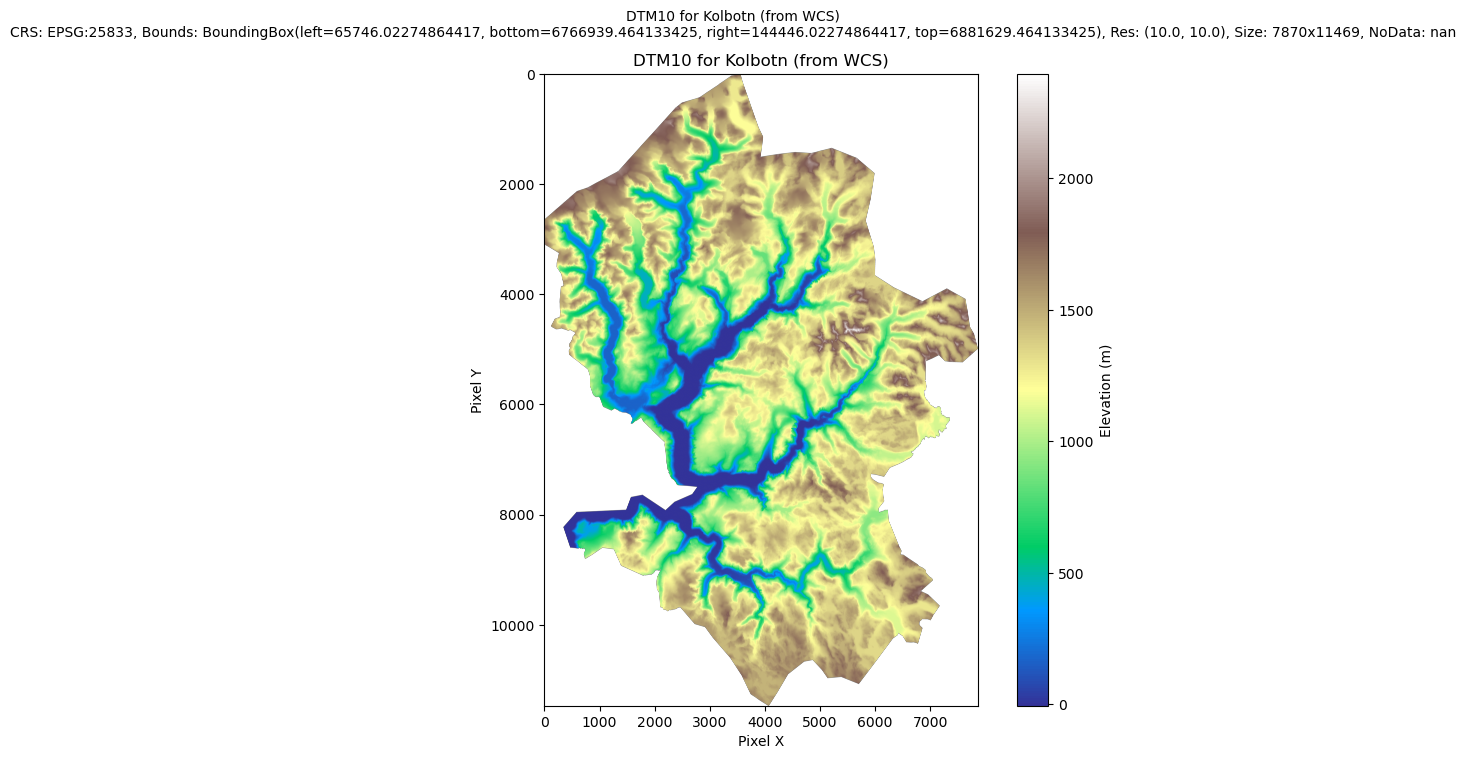

In [11]:
import rasterio
import matplotlib.pyplot as plt
dtm_sogn = Path("../data/raw/rasters/dtm10/tiles/sogn_dtm10.tif")
def plot_dtm(dtm_path):
    dtm_path = Path(dtm_path)
    info = []
    with rasterio.open(dtm_path) as src:
        print(f"\n--- {dtm_path.name} ---")
        print("CRS:", src.crs)
        print("Bounds:", src.bounds)
        print("Resolution:", src.res)
        print("Width x Height:", src.width, "x", src.height)
        print("NoData:", src.nodata)
        info.append((dtm_path.name, src.crs, src.bounds, src.res, src.width, src.height, src.nodata))

        dtm = src.read(1)
    return dtm, dtm_path.name, info


dtm_array, dtm_name, dtm_info = plot_dtm(dtm_sogn)
plt.figure(figsize=(10, 8))
plt.imshow(dtm_array, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title(f"DTM10 for Sogn (from WCS)")
plt.xlabel("Pixel X")
plt.ylabel("Pixel Y")
plt.subplots_adjust(top=0.9)
plt.suptitle(f"DTM10 for Sogn (from WCS)\nCRS: {dtm_info[0][1]}, Bounds: {dtm_info[0][2]}, Res: {dtm_info[0][3]}, Size: {dtm_info[0][4]}x{dtm_info[0][5]}, NoData: {dtm_info[0][6]}", fontsize=10)
plt.show()


--- sogn_dtm10.tif ---
CRS: EPSG:25833
Bounds: BoundingBox(left=65746.02274864417, bottom=6766939.464133425, right=144446.02274864417, top=6881629.464133425)
Resolution: (10.0, 10.0)
Width x Height: 7870 x 11469
NoData: nan


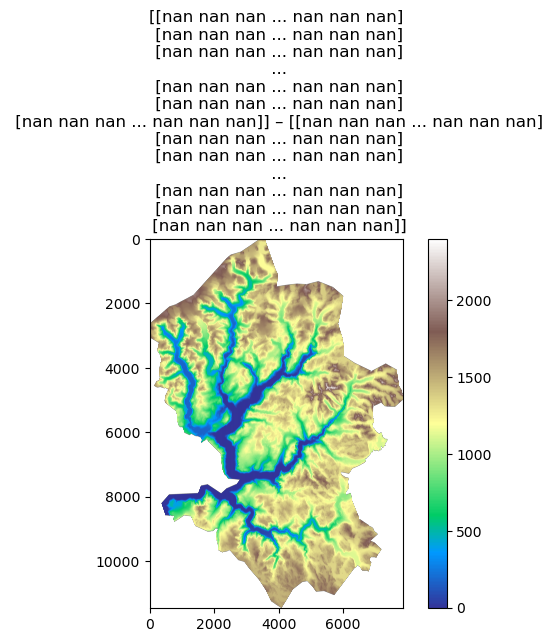


--- sogn_dtm10_filled.tif ---
CRS: EPSG:25833
Bounds: BoundingBox(left=65746.02274864417, bottom=6766939.464133425, right=144446.02274864417, top=6881629.464133425)
Resolution: (10.0, 10.0)
Width x Height: 7870 x 11469
NoData: -4.800000190734863

--- sogn_twi.tif ---
CRS: EPSG:25833
Bounds: BoundingBox(left=65746.02274864417, bottom=6766939.464133425, right=144446.02274864417, top=6881629.464133425)
Resolution: (10.0, 10.0)
Width x Height: 7870 x 11469
NoData: nan

--- sogn_aspect_deg.tif ---
CRS: EPSG:25833
Bounds: BoundingBox(left=65746.02274864417, bottom=6766939.464133425, right=144446.02274864417, top=6881629.464133425)
Resolution: (10.0, 10.0)
Width x Height: 7870 x 11469
NoData: nan


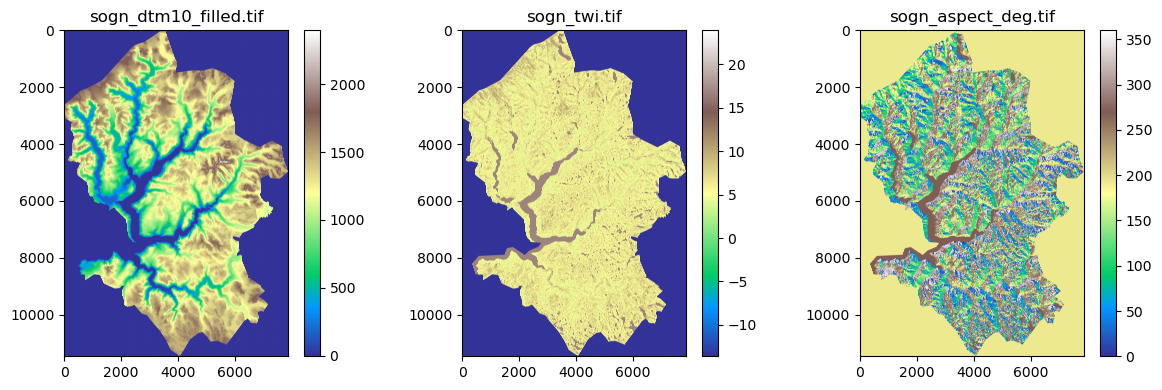

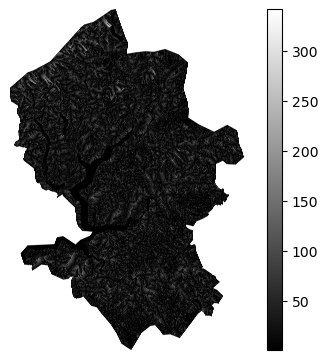

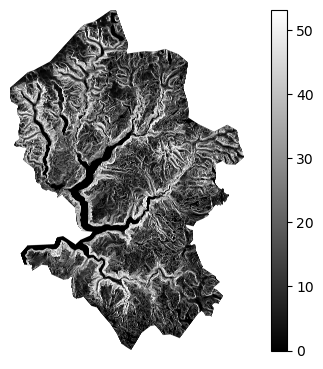

In [13]:
import numpy as np
import richdem as rd
def plot_dtm(dtm_path):
    dtm_path = Path(dtm_path)

    with rasterio.open(dtm_path) as src:
        print(f"\n--- {dtm_path.name} ---")
        print("CRS:", src.crs)
        print("Bounds:", src.bounds)
        print("Resolution:", src.res)
        print("Width x Height:", src.width, "x", src.height)
        print("NoData:", src.nodata)

        dtm = src.read(1)
    return dtm, dtm_path.name


def plot_curvature(curv_path):
    curv_path = Path(curv_path)

    with rasterio.open(curv_path) as src:
        arr = src.read(1).astype("float64")
        nodata = src.nodata

    if nodata is not None:
        arr = np.where(arr == nodata, np.nan, arr)

    # Robust limits
    vmin = np.nanpercentile(arr, 2)
    vmax = np.nanpercentile(arr, 98)

    # Make symmetric around 0 (nice for signed surfaces)
    lim = max(abs(vmin), abs(vmax))
    vmin, vmax = -lim, lim

    plt.figure(figsize=(7, 6))
    im = plt.imshow(arr, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    plt.colorbar(im)
    plt.title(curv_path.stem)
    plt.tight_layout()
    plt.show()
    
def plot_rd(tiles):
    for c in range(len(tiles)):
        loaded_tile = rd.LoadGDAL(tiles[c])
        rd.rdShow(loaded_tile, axes=False)
def plot_3(tiles):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for c in range(3):
        tile, name = plot_dtm(tiles[c])
# You can remove cmap if you want default styling
        ax = axes[c]
        ax.set_title(name)
        im = ax.imshow(tile, cmap="terrain")
        plt.colorbar(im, ax=ax)
        
    plt.tight_layout()
    plt.show()
    
def plot_all(dtm_path,raster_dir,region):
    dtm_path_filled = raster_dir / f"{region}_dtm10_filled.tif"
    twi_path = raster_dir / f"{region}_twi.tif"
    aspect_path = raster_dir / f"{region}_aspect_deg.tif"
    flowacc_path = raster_dir / f"{region}_flowacc_d8.tif"
    slope_path = raster_dir / f"{region}_slope_deg.tif"
    dtm, name = plot_dtm(dtm_path)
    plt.figure()
    plt.imshow(dtm, cmap="terrain")  # for slope/TWI/DEM works fine
    plt.colorbar()
    plt.title(f"{dtm} – {dtm}")
    plt.show()
    tiles = [dtm_path_filled,twi_path,aspect_path]
    tiles_2 = [flowacc_path,slope_path]
    plot_3(tiles)
    plot_rd(tiles_2)
    
    
dtm_path = Path("../data/raw/rasters/dtm10/tiles/sogn_dtm10.tif")
raster_dir = Path("../data/processed/regions/sogn/rasters")
plot_all(dtm_path,raster_dir,"sogn")
